# Exploratory Data Analysis

In [18]:
# importiamo i pacchetti necessari
import numpy as np 
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

import json

from pathlib import Path
from shapely.geometry import Point
from shapely.geometry import shape

# importazione del modulo con le funzioni
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('..')

from IPython.display import Image, display
import src.EDA_funcs as fs

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# importiamo il dataframe salvato
dataframe_df = pd.read_csv('../data/processed/dataset_EDA_processed.csv')

## Studio meteo
Iniziamo dando un'occhiata ai dati sul meteo, cercando di capire se ci siano trend temporali.

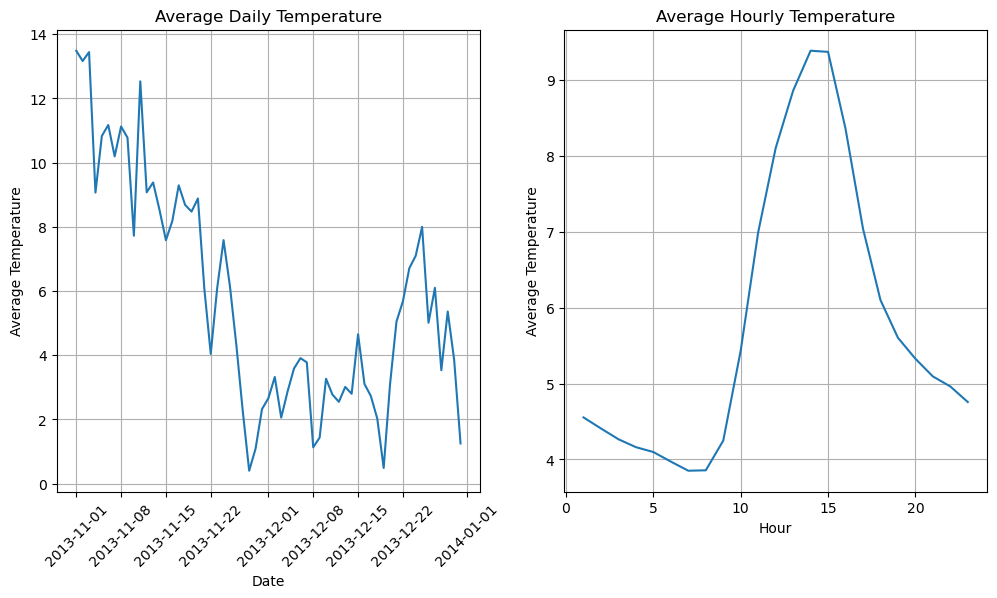

In [3]:
# Osserviamo l'andamento della temperatura in funzione dell'ora e del giorno:
hourly_temp = (dataframe_df.groupby(['hour'])['temperature'].mean().reset_index())
daily_temp = (dataframe_df.groupby(['date'])['temperature'].mean().reset_index())
daily_temp['date'] = pd.to_datetime(daily_temp['date'])

fig, axes = plt.subplots(1, 2, figsize=(12,6))

ax1 = axes[0]
ax1.plot(daily_temp['date'], daily_temp['temperature'])
ax1.set_xlabel('Date')
ax1.set_ylabel('Average Temperature')
ax1.set_title('Average Daily Temperature')
ax1.tick_params(axis='x', labelrotation=45)
ax1.grid(True)

ax2 = axes[1]
ax2.plot(hourly_temp['hour'], hourly_temp['temperature'])
ax2.set_xlabel('Hour')
ax2.set_ylabel('Average Temperature')
ax2.set_title('Average Hourly Temperature')
ax2.grid(True)

plt.show()

Chiaramente la temperatura decresce passando da Novembre a Dicembre e dimostra un chiaro trend nel corso della giornata, con un minimo alle 7 di mattina e un massimo alle due del pomeriggio. Nessuno di questi comportamenti ci sorprende.

La velocità del vento ha qualche trend?

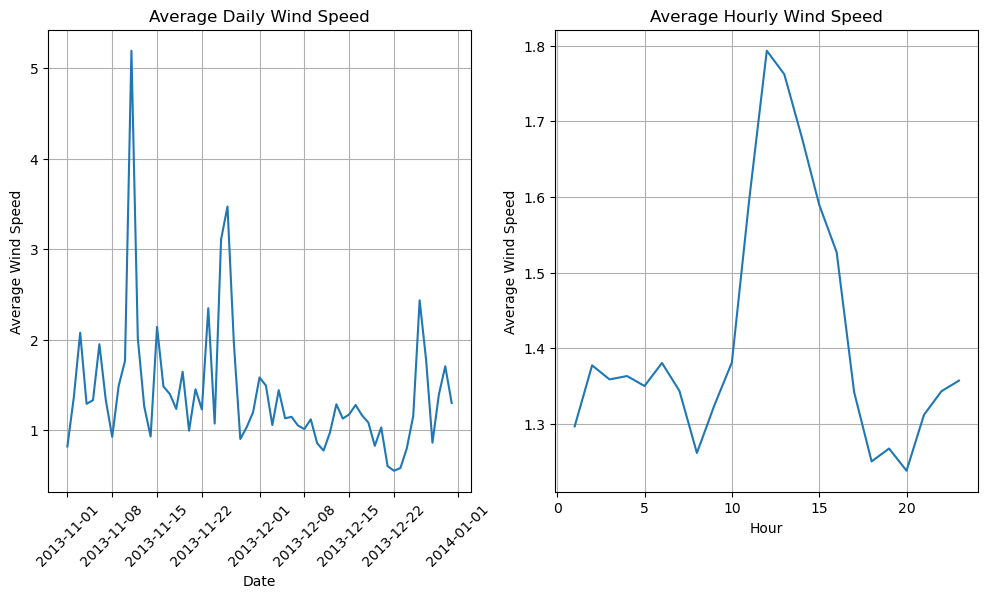

In [4]:
daily_wind = (dataframe_df.groupby(['date'])['winds_spd'].mean().reset_index())
hourly_wind = (dataframe_df.groupby(['hour'])['winds_spd'].mean().reset_index())
daily_wind['date'] = pd.to_datetime(daily_wind['date'])

fig, axes = plt.subplots(1, 2, figsize=(12,6))

ax1 = axes[0]
ax1.plot(daily_wind['date'], daily_wind['winds_spd'])
ax1.set_xlabel('Date')
ax1.set_ylabel('Average Wind Speed')
ax1.set_title('Average Daily Wind Speed')
ax1.tick_params(axis='x', labelrotation=45)
ax1.grid(True)

ax2 = axes[1]
ax2.plot(hourly_wind['hour'], hourly_wind['winds_spd'])
ax2.set_xlabel('Hour')
ax2.set_ylabel('Average Wind Speed')
ax2.set_title('Average Hourly Wind Speed')
ax2.grid(True)

plt.show()

Non osserviamo un andamento chiaro nell'andamento della velocità del vento nel periodo studiato. Tuttavia appare chiaro che la velocità del vento è maggiore tra le 10 e le 16. Questo è imputabile al Sole che splende maggiormente in quell'orario, riscaldando l'atmosfera e di conseguenza aumentando l'energia cinetica delle molecole e incrementando le turbolenze.

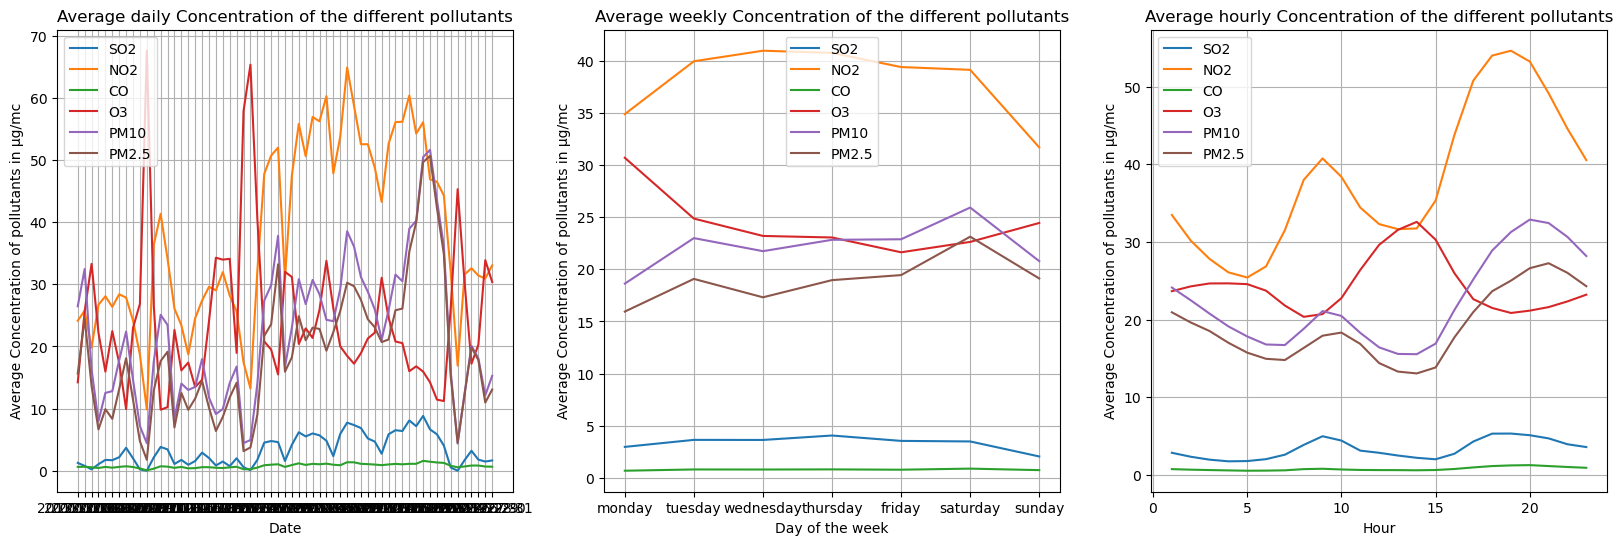

In [5]:
pols = ['SO2', 'NO2', 'CO', 'O3', 'PM10', 'PM2.5']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
ax1, ax2, ax3 = axes

for p in pols:
    daily_p = (dataframe_df.groupby(['date'])[p].mean().reset_index())
    weekly_p = (dataframe_df.groupby(['week_day'])[p].mean().reset_index())
    week_order = ['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday']
    weekly_p['week_day'] = pd.Categorical(weekly_p['week_day'],categories=week_order,ordered=True)
    weekly_p = weekly_p.sort_values('week_day')

    hourly_p = (dataframe_df.groupby(['hour'])[p].mean().reset_index())

    ax1.plot(daily_p['date'], daily_p[p])
    ax2.plot(weekly_p['week_day'], weekly_p[p])
    ax3.plot(hourly_p['hour'], hourly_p[p])

ax1.set_xlabel('Date')
ax1.set_ylabel('Average Concentration of pollutants in µg/mc')
ax1.set_title('Average daily Concentration of the different pollutants')
ax1.legend(pols)
ax1.grid(True)

ax2.set_xlabel('Day of the week')
ax2.set_ylabel('Average Concentration of pollutants in µg/mc')
ax2.set_title('Average weekly Concentration of the different pollutants')
ax2.legend(pols)
ax2.grid(True)

ax3.set_xlabel('Hour')
ax3.set_ylabel('Average Concentration of pollutants in µg/mc')
ax3.set_title('Average hourly Concentration of the different pollutants')
ax3.legend(pols)
ax3.grid(True)

plt.show()

È difficile confrontare accuratamente il comportamento dei diversi inquinanti poiché appartengono ad ordini di grandezza differenti, in particolar modo il monossido di carbonio, quindi disegnamo di ciascuno l'andamento in scala rispetto al proprio massimo

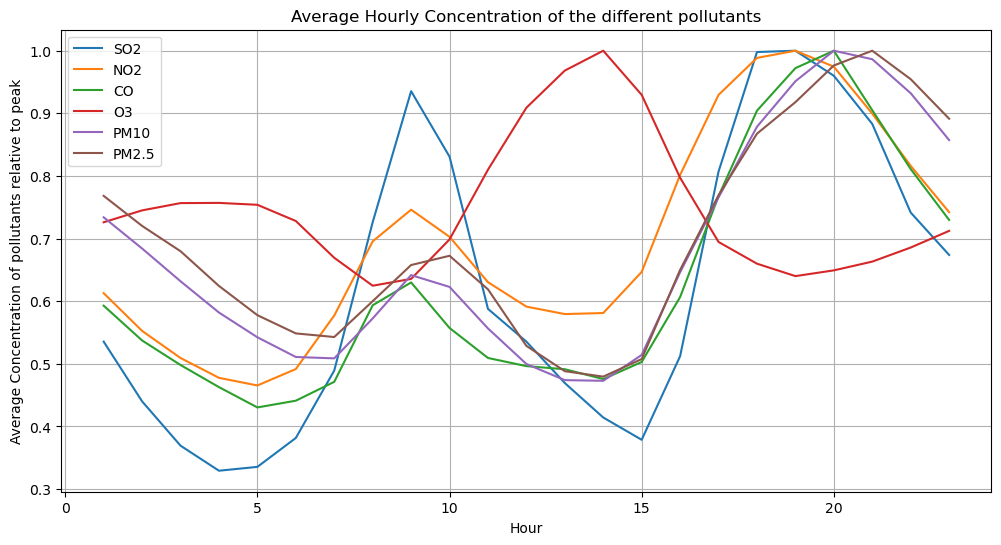

In [6]:
plt.figure(figsize=(12,6))

for p in pols:
    hourly_p = (dataframe_df.groupby(['hour'])[p].mean().reset_index())
    hourly_p[p] = hourly_p[p] / max(hourly_p[p])
    plt.plot(hourly_p['hour'], hourly_p[p])


plt.xlabel('Hour')
plt.ylabel('Average Concentration of pollutants relative to peak')
plt.title('Average Hourly Concentration of the different pollutants')
plt.legend(pols)
plt.grid(True)

Appare chiaro che, ad eccezione dell'Ozono (che segue un trend opposto) tutti gli inquinanti si comportano allo stesso modo, esibendo alte concentrazioni attorno alle 9 di mattina  e tra le 7 e le 9 di sera mentre l'aria è più pulita attorno alle 6 di mattina e alle 2 del pomeriggio. Questo comportamento così evidente è sensato poiché queste sostanze inquinanti sono prodotte principalmente da attività umane e, pertanto, è sensato che seguano i ritmi quotidiani della società.

Tracciamo anche l'andamento della qualità dell'aria al variare di ora, giorno della settimana e in generale nell'intero periodo studiato.

In [7]:
# scegliamo un ordine di colori intuitivo
category_order = ['very poor', 'poor', 'moderate', 'fair', 'good']
colors = {'good': 'green', 'fair': 'yellowgreen', 'moderate': 'yellow', 'poor': 'orange', 'very poor': 'red'}

# non vogliamo alterare il nostro dataframe originale
histogram_df = dataframe_df.copy()
histogram_df['EAQI'] = pd.Categorical(histogram_df['EAQI'], categories=category_order, ordered=True)

/var/folders/kk/q9vd_8nn5w5cp7fcpz9zs4sh0000gn/T/ipykernel_6878/2114340544.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = (histogram_df.groupby(['hour', 'EAQI']).size().unstack(fill_value=0))


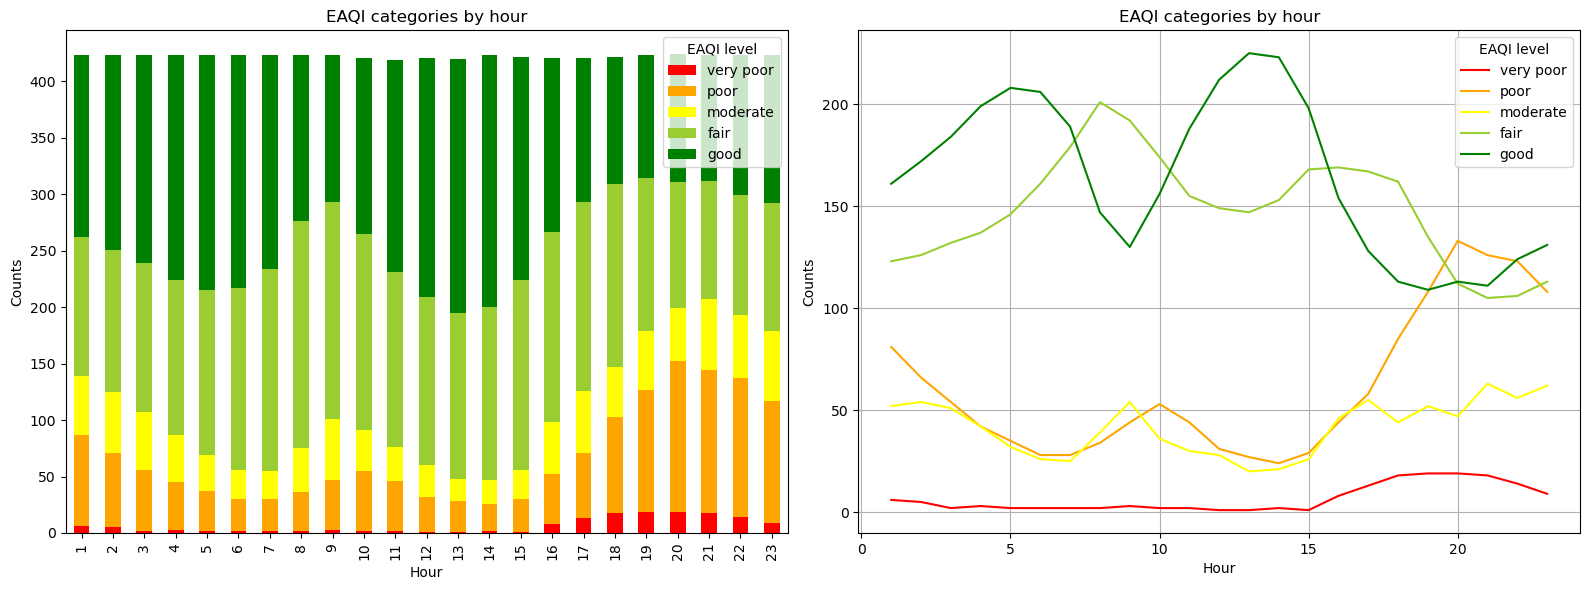

In [8]:
# contiamo il numero di osservazioni per ogni combinazione di ora e categoria EAQI
counts = (histogram_df.groupby(['hour', 'EAQI']).size().unstack(fill_value=0))
counts = counts[category_order]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
counts.plot(kind='bar', stacked=True, color=[colors[c] for c in category_order], ax=axes[0])
counts.plot(color=[colors[c] for c in category_order], ax = axes[1])

axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Counts')
axes[0].set_title('EAQI categories by hour')
axes[0].legend(title='EAQI level')

axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Counts')
axes[1].set_title('EAQI categories by hour')
axes[1].legend(title='EAQI level')
axes[1].grid(True)

plt.tight_layout()
plt.show()

Questi grafici indicano che la qualità dell'aria è migliore attorno alle 6 e alle 14 mentre peggiora significativamente tra le 20 e le 21. Questo si allinea alle osservazioni effettuate precedentemente per i singoli inquinanti.

/var/folders/kk/q9vd_8nn5w5cp7fcpz9zs4sh0000gn/T/ipykernel_6878/967748989.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = (histogram_df.groupby(['week_day', 'EAQI']).size().unstack(fill_value=0))


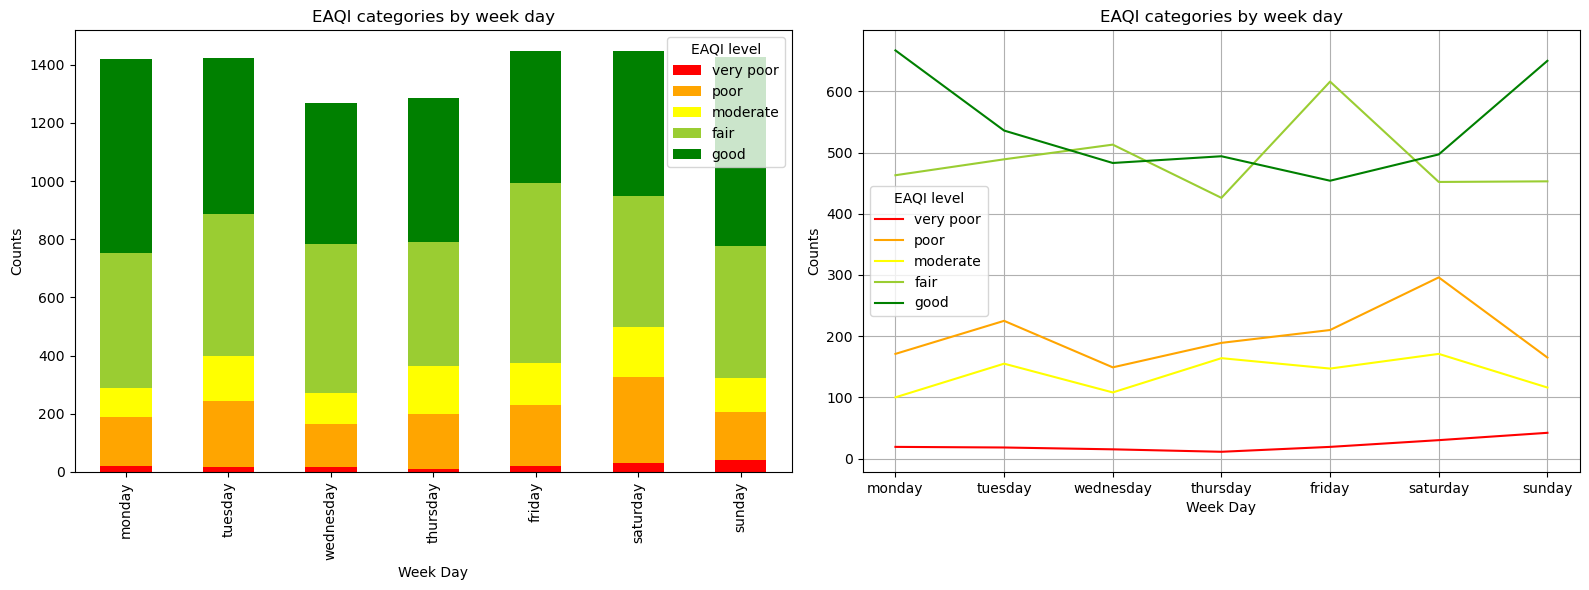

In [9]:
week_order = ['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday']
histogram_df['week_day'] = pd.Categorical(histogram_df['week_day'],categories=week_order,ordered=True)
histogram_df = histogram_df.sort_values('week_day')

# contiamo il numero di osservazioni per ogni combinazione di giorno della settimana e categoria EAQI
counts = (histogram_df.groupby(['week_day', 'EAQI']).size().unstack(fill_value=0))
counts = counts[category_order]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
counts.plot(kind='bar', stacked=True, color=[colors[c] for c in category_order], ax=axes[0])
counts.plot(color=[colors[c] for c in category_order], ax = axes[1])

axes[0].set_xlabel('Week Day')
axes[0].set_ylabel('Counts')
axes[0].set_title('EAQI categories by week day')
axes[0].legend(title='EAQI level')

axes[1].set_xlabel('Week Day')
axes[1].set_ylabel('Counts')
axes[1].set_title('EAQI categories by week day')
axes[1].legend(title='EAQI level')
axes[1].grid(True)

plt.tight_layout()
plt.show()

/var/folders/kk/q9vd_8nn5w5cp7fcpz9zs4sh0000gn/T/ipykernel_6878/2964587124.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = (histogram_df.groupby(['date', 'EAQI']).size().unstack(fill_value=0))


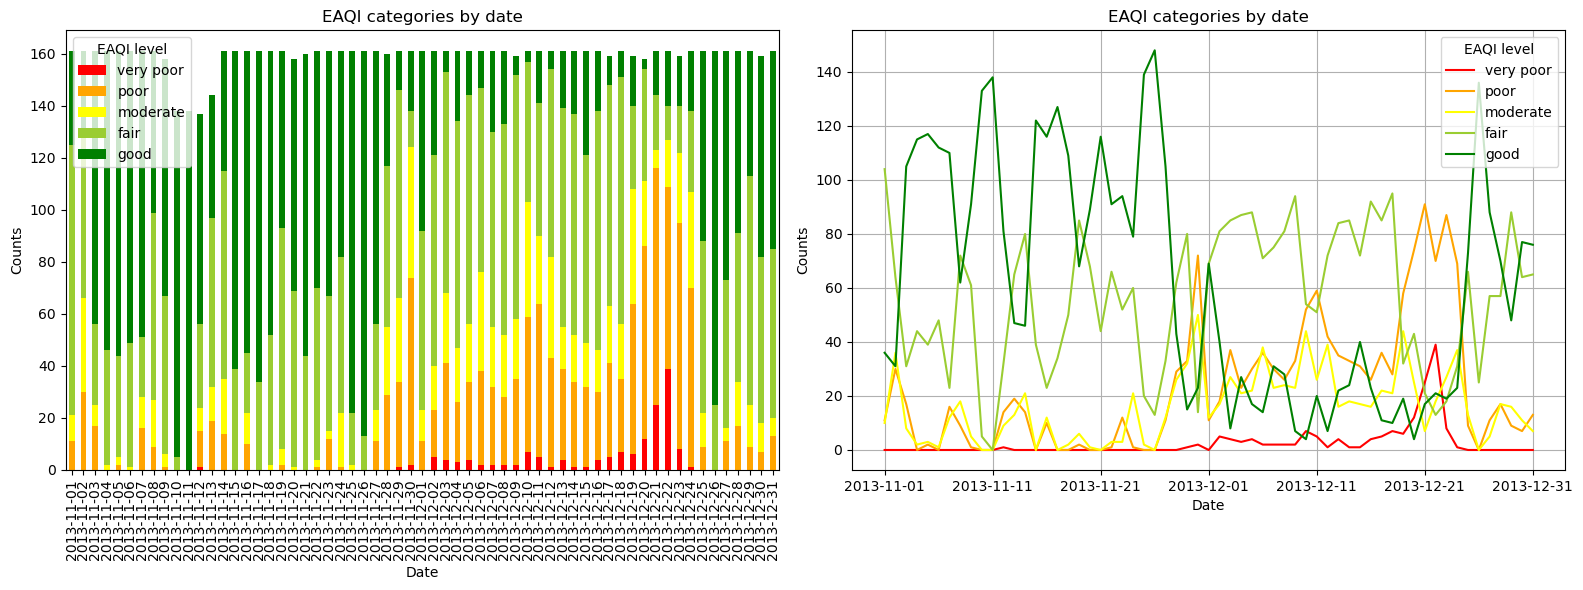

In [10]:
# proviamo infine a rappresentare in un istogramma l'andamento dell'EAQI in funzione del giorno in modo da vedere eventuali trend mensili o picchi legati a giorni
# specifici

# contiamo il numero di osservazioni per ogni combinazione di giorno e categoria EAQI
counts = (histogram_df.groupby(['date', 'EAQI']).size().unstack(fill_value=0))
counts = counts[category_order]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
counts.plot(kind='bar', stacked=True, color=[colors[c] for c in category_order], ax=axes[0])
counts.plot(color=[colors[c] for c in category_order], ax = axes[1])

axes[0].set_xlabel('Date')
axes[0].set_ylabel('Counts')
axes[0].set_title('EAQI categories by date')
axes[0].legend(title='EAQI level')

axes[1].set_xlabel('Date')
axes[1].set_ylabel('Counts')
axes[1].set_title('EAQI categories by date')
axes[1].legend(title='EAQI level')
axes[1].grid(True)

plt.tight_layout()
plt.show()

Sembra che in media la qualità dell'aria peggiori nel corso dei mesi, culminando qualche giorno prima della vigilia di Natale, per poi scendere rapidamente. Ci si può aspettare che questo picco sia dato da un misto di temperature minori, per cui le case devono essere riscaldate di più, e di un aumento delle attività umane, che culminano proprio subito prima di Natale e diminuiscono con l'inizio delle vacanze invernali.

Da questo punto di vista sarebbe interessante studiare la correlazione tra gli inquinanti e la distanza dal giorno di Natale.

<Axes: >

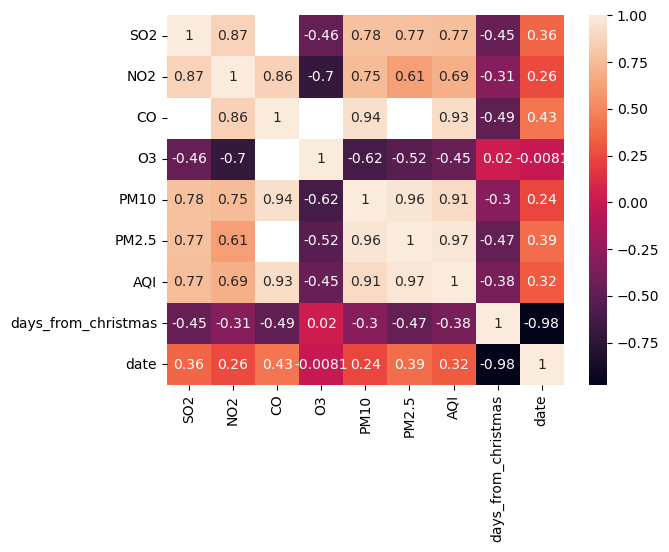

In [11]:
# copiamo il dataframe ed inseriamo una colonna con la distanza (in valore assoluto) dal 22 dicembre, che possiamo assumere essere il giorno
# di massima attività
christmas_df = dataframe_df.copy()
christmas_df['date'] = pd.to_datetime(christmas_df['date'])
christmas_date = pd.to_datetime('2013-12-22')
christmas_df['days_from_christmas'] = (christmas_df['date'] - christmas_date).dt.days.abs()


pol_cols = ['SO2', 'NO2', 'CO', 'O3', 'PM10', 'PM2.5', 'AQI']
sns.heatmap(christmas_df[pol_cols + ['days_from_christmas', 'date']].corr(), annot=True)

Come atteso, gli inquinanti sembrano tutti correlati negativamente rispetto alla distanza da Natale. L'unico inquinante che sembra non essere influenzato da questa distanza è l'ozono, che come sempre ha tendenze molto diverse dal resto degli inquinanti

Abbiamo provato ad includere questa feature nell'allenamento dei modelli ma non si è rivelata particolarmente utile e, pertanto, non sarà riportata successivamente.

#### AQI e stazioni
Concludiamo questo studio cronologico studiando l'andamento del valore AQI in funzione della stazione di rilevamento. In questo modo possiamo capire se ci sono stazioni che tendono ad avere valori di AQI più alti o più bassi, e se questa tendenza è più marcata per alcuni inquinanti rispetto ad altri.

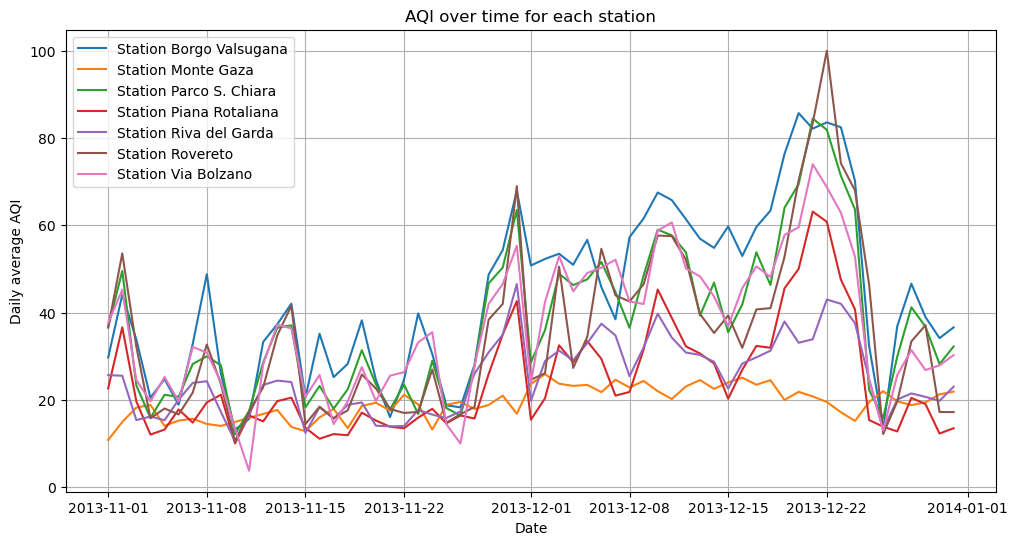

In [12]:
plt.figure(figsize=(12,6))
for station in dataframe_df['station_appa'].unique():
    station_data = dataframe_df[dataframe_df['station_appa'] == station].copy()
    station_data['mean_AQI'] = station_data.groupby('date')['AQI'].transform('mean')
    station_data['date'] = pd.to_datetime(station_data['date'])
    plt.plot('date', 'mean_AQI', data=station_data, label=f'Station {station}')

plt.xlabel('Date')
plt.ylabel('Daily average AQI')
plt.title('AQI over time for each station')
plt.legend()
plt.grid(True)
plt.show()

Questo grafico ci mostra innanzitutto un andamento medio nel tempo molto simile per la maggior parte delle stazioni. Permettendoci di ritrovare l'andamento crescente verso natale visto sopra.

Nota particolarmente interessante è la stazione di Monte Gaza, che sembra rilevare un inquinamento dell'aria in generale molto più basso rispetto alle altre stazioni. Probabilmente questo fatto è dovuto alla collocazione particolarmente isolata di questa stazione.

Riva del Garda e Piana Rotaliana sembrano combattersela per il secondo posto in quanto a bontà dell'aria, ma Riva del Garda sarà particolarmente poco rilevante durante la classificazione per la mancanza di dati legati alla potenza elettrica.

### Correlazione con le feature
Studiamo ora le correlazioni tra le varie feature del nostro dataframe, in modo da capire quali feature abbiano andamenti correlati all'andamento degli inquinanti.

#### Inquinanti vs rilevazioni meteo

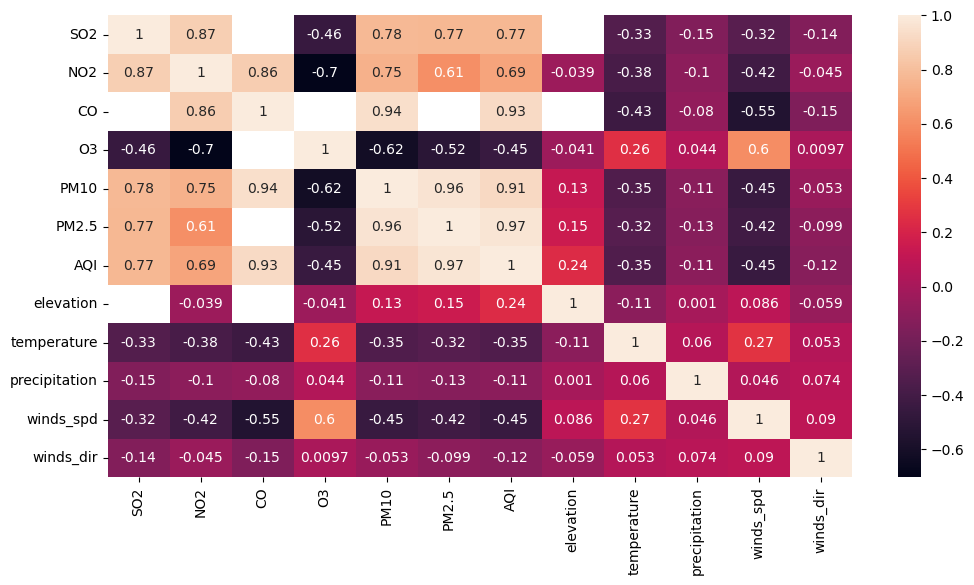

In [13]:
# c'è correlazione tra temperature - precipitation - wind - pollutants? 
corr_df = dataframe_df.copy()

analyzed_features = ['SO2', 'NO2', 'CO', 'O3', 'PM10', 'PM2.5', 'AQI', 'elevation', 'temperature', 'precipitation', 'winds_spd', 'winds_dir']

fig, axes = plt.subplots(1, 1, figsize=(12, 6))
sns.heatmap(corr_df[analyzed_features].corr(), annot=True, ax=axes)

plt.show()


La matrice di correlazione indica alcuni trend interessanti:
-  Nel quadrato di dati relativi agli inquinanti, sono presenti alcuni buchi, questo è indice del fatto che non tutte le stazioni APPA registrano dati per tutti gli inquinanti. Per alcune coppie di inquinanti, infatti, non è presente una stazione che li registri entrambi e, pertanto, non è possibile stabilire una correlazione.
-  Ad eccezione dell'ozono, tutti gli inquinanti sono fortemente correlati positivamente tra loro, mentre l'ozono mostra una forte anticorrelazione rispetto agli altri. Questo è perfettamente in accordo con il grafico tracciato prima.
-  Temperatura e velocità del vento sono correlate positivamente. Questo è imputabile al maggiore movimento delle particelle calde che risulta in più turbolenze e quindi venti più intensi.
-  È chiara l'anticorrelazione tra temperatura e velocità del vento da una parte e inquinanti dall'altra. Come sopra, l'ozono si muove in controtendenza rispetto agli altri inquinanti.
- Si notano diverse correlazioni tra gli inquinanti e le misure meteo. Tra queste, particolarmente interessanti sono la correlazione fortemente negativa tra inquinanti e forza del vento e leggermente negativa tra inquinanti e elevazione.
- Al contrario di come ci si aspetterebbe, sembra che le precipitazioni correlino solo leggermente con gli inquinanti. Vogliamo approfondire questo aspetto.

Come accennato sopra, le precipitazioni appaiono indipendenti rispetto a tutte le altre grandezze analizzate. Questo differisce da ciò che ci suggerisce l'intuito. Infatti, ci aspetteremmo che la pioggia abbassi la temperatura e riduca la concentrazione di inquinanti nell'aria. Ipotizziamo che questa mancata correlazione possa essere dovuta al fatto che gli effetti delle precipitazioni sono avvertiti con un certo ritardo. Proviamo quindi a traslare indietro nel tempo la colonna delle precipitazioni e verificare se la correlazione aumenta, diminuisce oppure rimane invariata.

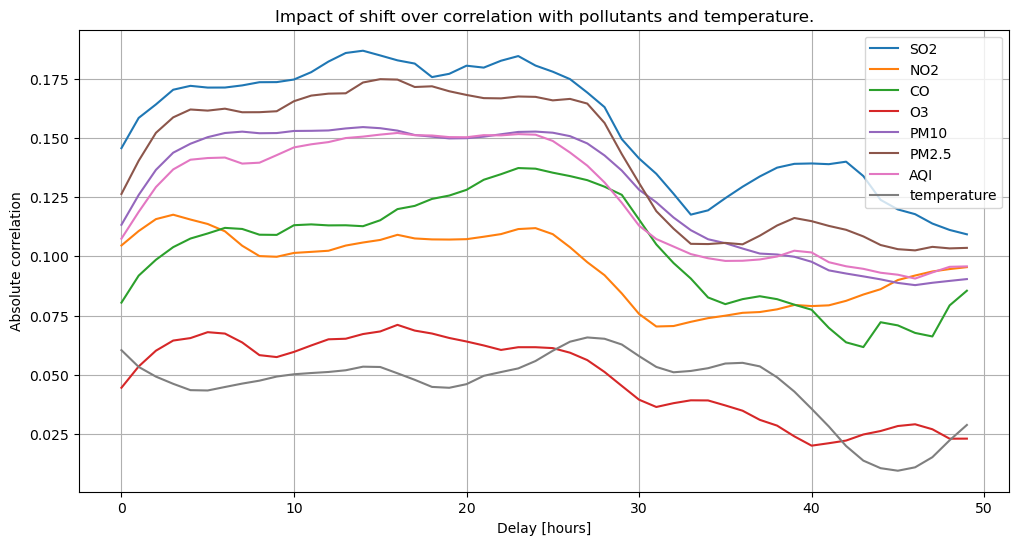

In [14]:
delay_df = dataframe_df.copy()

plt.figure(figsize=(12,6))

possible_shifts = range(0, 50)

interesting_features = ['SO2', 'NO2', 'CO', 'O3', 'PM10', 'PM2.5', 'AQI', 'temperature']
for p in interesting_features:
    
    shifts = {}

    for ps in possible_shifts:
        
        shifted = fs.shift_prec(delay_df, hours=ps)
        
        corr = shifted.corr(delay_df[p])
        
        shifts[ps] = abs(corr)
    
    plt.plot(shifts.keys(), shifts.values())

    
plt.xlabel("Delay [hours]")
plt.ylabel("Absolute correlation")
plt.title('Impact of shift over correlation with pollutants and temperature.')
plt.grid(True)
plt.legend(interesting_features)
plt.show()

Vediamo che, ad eccezione della temperatura, aggiungere un ritardo di poche ore rafforza la correlazione tra precipitazione ed inquinanti. Chiaramente dopo una certa soglia la correlazione si indebolisce visto il grande intervallo temporale che intercorre tra le precipitazioni e gli inquinanti. 

In ogni caso le precipitazioni continuano a correlare veramente poco con gli inquinanti. Senza escludere proprio questa feature a priori, in fase di classificazione useremo solamente le precipitazioni 5 ore prima in modo da non appesantire troppo l'allenamento e ridurre l'overfitting. Nello studio giornaliero, invece, consideriamo unicamente i dati relativi alle precipitazioni del giorno precedente.

In generale anche per features come la temperatura e la velocità del vento in realtà non possiamo usare i dati alla stessa ora degli inquinanti, visto che vogliamo essere in grado di predire con un'ora di anticipo e non possiamo dare al modello dati futuri. Assumiamo tuttavia che queste features non cambino troppo velocemente nel tempo e quindi usiamo come features per il training temperatura e vento un'ora prima o un giorno prima a seconda dello studio.

#### Inquinanti vs consumi elettrici

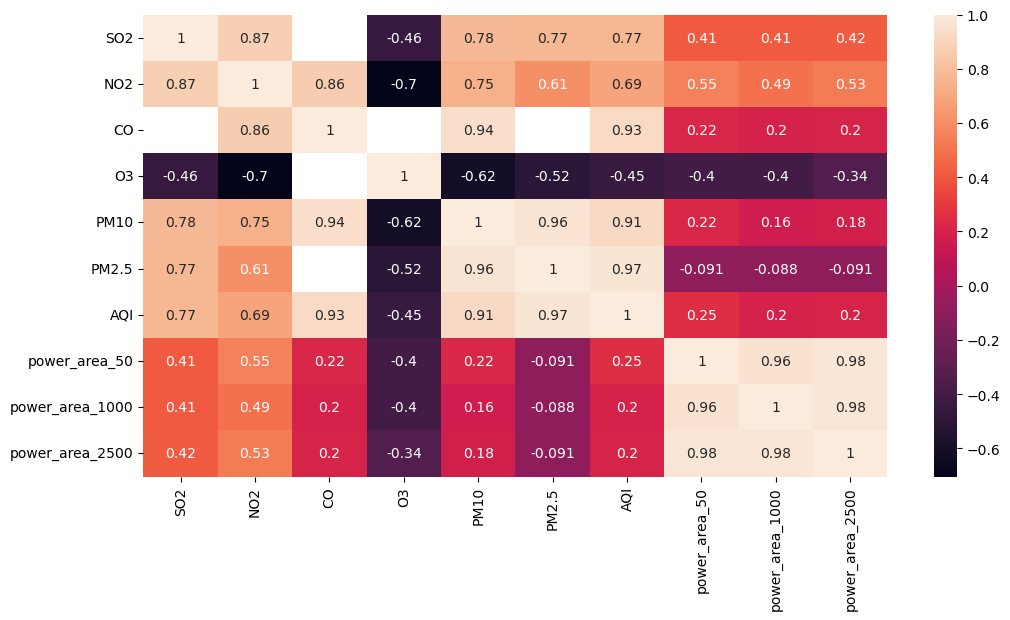

In [15]:
# c'è una correlazione tra i vari inquinanti ed i consumi energetici?
corr_df = dataframe_df.copy()

analyzed_features = ['SO2', 'NO2', 'CO', 'O3', 'PM10', 'PM2.5', 'AQI', 'power_area_50', 'power_area_1000', 'power_area_2500']

fig, axes = plt.subplots(1, 1, figsize=(12, 6))
sns.heatmap(corr_df[analyzed_features].corr(), annot=True, ax=axes)

plt.show()

In generale i consumi elettrici sembrano abbastanza correlati con tutti gli inquinanti (con la solita correlazione opposta per l'ozono). Questo avvalora il discorso fatto in precedenza sulla relazione tra potenza dissipata e produzione di inquinanti atmosferici. Quello che vorremmo capire ora, al fine della successiva classificazione, è come evolva questa correlazione per le ore precedenti a quella di interesse.\
Procediamo quindi con uno studio simile a quello delle precipitazioni, ma per le tre colonne della potenza.

Studiamo innanzitutto la potenza entro 50 metri e capiamo come correli rispetto a diversi shift temporali.

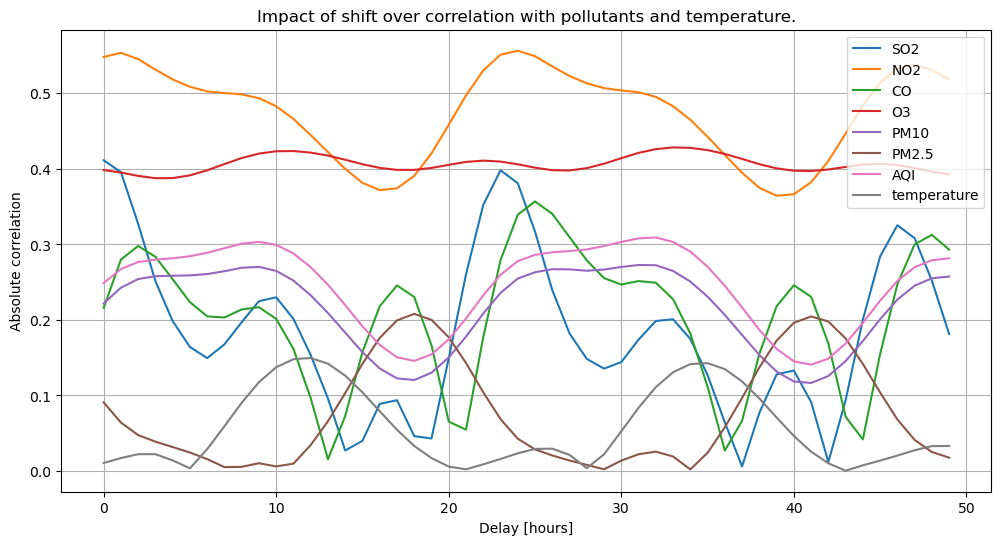

In [16]:
delay_df = dataframe_df.copy()

plt.figure(figsize=(12,6))

possible_shifts = range(0, 50)

interesting_features = ['SO2', 'NO2', 'CO', 'O3', 'PM10', 'PM2.5', 'AQI', 'temperature']
for p in interesting_features:
    
    shifts = {}

    for ps in possible_shifts:
        
        shifted = fs.shift_prec(delay_df, hours=ps, col_name='power_area_50',)
        
        corr = shifted.corr(delay_df[p])
        
        shifts[ps] = abs(corr)
    
    plt.plot(shifts.keys(), shifts.values())

    
plt.xlabel("Delay [hours]")
plt.ylabel("Absolute correlation")
plt.title('Impact of shift over correlation with pollutants and temperature.')
plt.grid(True)
plt.legend(interesting_features)
plt.show()

Notiamo una chiara periodicità di circa un giorno sulla potenza. Questo è probabilmente dovuto al fatto che, assumendo una periodicità giornaliera sul consumo di energia elettrica, il dato sulla potenza del giorno prima sarà molto simile al dato nella ora di interesse e pertanto la correlazione sarà molto simile a quella nell'istante stesso.

Allo stesso tempo sembra che molti inquinanti siano più correlati con l'ora precedente che con l'ora stessa, per cui i dati sulla potenza nelle ore appena precedenti a quella desiderata, sono sicuramente dei dati validi.

Passiamo quindi a confrontare la potenza sui diversi raggi, restringendo il nostro interesse all'AQI.

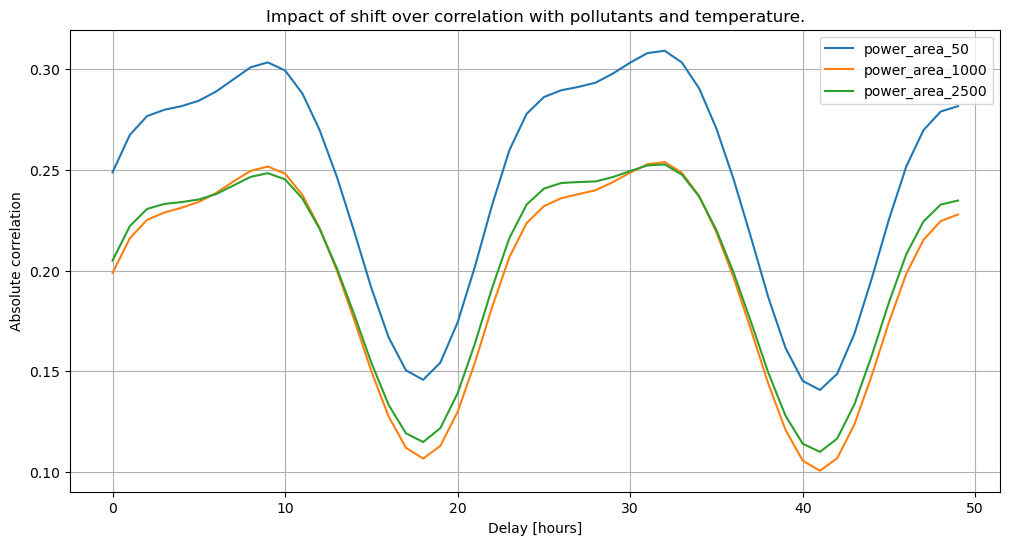

In [17]:
delay_df = dataframe_df.copy()

plt.figure(figsize=(12,6))

possible_shifts = range(0, 50)

power_cols = ['power_area_50', 'power_area_1000', 'power_area_2500']
for p in power_cols:
    
    shifts = {}

    for ps in possible_shifts:
        
        shifted = fs.shift_prec(delay_df, hours=ps, col_name=p,)
        
        corr = shifted.corr(delay_df['AQI'])
        
        shifts[ps] = abs(corr)
    
    plt.plot(shifts.keys(), shifts.values())

    
plt.xlabel("Delay [hours]")
plt.ylabel("Absolute correlation")
plt.title('Impact of shift over correlation with pollutants and temperature.')
plt.grid(True)
plt.legend(power_cols)
plt.show()

Il dato sulla potenza a 50 metri è sicuramente quello più correlato a qualsiasi ora di delay. Da un certo punto di vista spieghiamo questa cosa pensando al fatto che se effettivamente gli inquinanti sono legati all'attività umana, a noi interessa solo l'attività umana locale, mentre considerare aree più grandi è fonte sostanzialmente solo di rumore.

D'altro canto, questo risultato fa cadere un po' tutta la nostra assunzione sulla dinamica degli inquinanti nell'atmosfera. Evidentemente l'effetto della dispersione degli inquinanti è molto meno rilevante di quanto pensassimo precedentemente.

Nella classificazione considereremo pertanto solo la potenza dissipata entro 50 metri.